# Model Bundle Workflow Example

This notebook demonstrates the model bundle workflow for saving and loading trained gap-filling models with all necessary metadata and statistics.

## Why Use Model Bundles?

A model bundle packages together:
- The trained TensorFlow/Keras model
- Standardization statistics (mean, stdev)
- Training metadata (region, dates, configuration)
- Training history

This ensures reproducible gap-filling workflows by keeping all artifacts together.

In [3]:
#%pip install -q git+https://github.com/SAFS-Varanasi-Internship/mindthegap.git@main
%pip install -e ..

Obtaining file:///home/jovyan/mindthegap
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for mindthegap (pyproject.toml) ... done
  Created wheel for mindthegap: filename=mindthegap-0.1.0-0.editable-py3-none-any.whl size=6307 sha256=3a692618ef5cdbbad4fce149cb7b8b3baaeaa6d12adfe6bcb5e39366378600a7
  Stored in directory: /tmp/pip-ephem-wheel-cache-rxqm6fc8/wheels/bf/33/56/bda8a265cbf6abb8b49f20ef4e8f99a5cafc428b704405201e
Successfully built mindthegap
Note: you may need to restart the kernel to use updated packages.


In [1]:
import tensorflow as tf
zarr_label="2015_3_ArabSea"
model_name="UNet_DoubleConv_mse"
model_dir="/home/jovyan/mindthegap/models"
model = tf.keras.models.load_model(f'{model_dir}/{zarr_label}/{model_name}.keras')

I0000 00:00:1783707105.942974   17603 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783707106.000582   17603 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783707109.623950   17603 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1783707111.125114   17603 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
import xarray as xr
import mindthegap as mtg
import numpy as np
zarr_stdized = xr.open_dataset(
    "gcs://nmfs_odp_nwfsc/CB/mind_the_chl_gap/2015_3_ArabSea.zarr",
    engine="zarr",
    backend_kwargs={"storage_options": {"token": "anon"}},
    consolidated=True,
    chunks={}
)
vars_to_use = ['CHL',
 'cos_time',
 'fake_cloud_flag',
 'land_flag',
 'masked_CHL',
 'next_day-CHL',
 'prev_day_CHL',
 'real_cloud_flag',
 'sin_time',
 'sst',
 'valid_CHL_flag']
zarr_stdized = zarr_stdized[vars_to_use]
ds_cropped = mtg.crop_to_multiple(zarr_stdized, multiple=8)

# need the mean and std of CHL
datadir = "/home/jovyan/shared-public/mindthegap/data"
stats = np.load(f'{datadir}/{zarr_label}.npy', allow_pickle='TRUE').item()


(array([51470848., 23648768., 18084352., 18084352., 15302144., 16693248.,
        16693248., 19475456., 22257664., 52340288.]),
 array([-1.41493773e+00, -1.13217354e+00, -8.49409461e-01, -5.66645324e-01,
        -2.83881187e-01, -1.11699104e-03,  2.81647086e-01,  5.64411163e-01,
         8.47175360e-01,  1.12993956e+00,  1.41270363e+00]),
 <BarContainer object of 10 artists>)

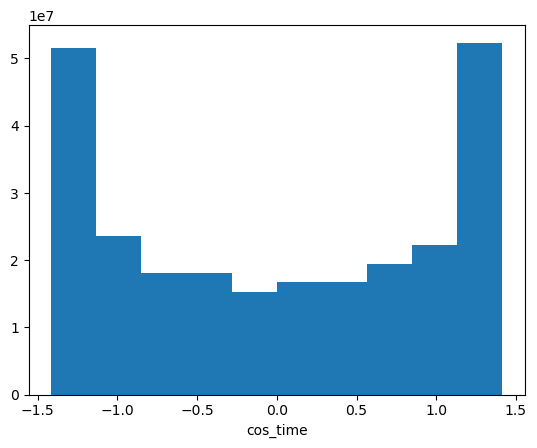

In [5]:
ds_cropped.cos_time.plot()

In [ ]:
import mindthegap as mtg

# After training (see 2-U-Net_Fit.ipynb for full training code):
# model = mtg.UNet(input_shape=(40, 56, 11))
# history = model.fit(train_dataset, validation_data=val_dataset, epochs=50)
# ds_train, stats = mtg.build_standardized_lazy(...)

# Save the complete bundle
# Note: ds_train is required to capture variable names and order
bundle = mtg.save_model_bundle(
    model=model,
    bundle_path="models/arabsea_2015_bundle",
    stats=stats,
    ds_train=ds_train,  # Required: training dataset to capture variable order
    metadata={
        "target_variable": "CHL",  # Required: specify the target variable
        "region": "Arabian Sea",
        "train_year": 2015,
        "train_range": 3,
        "patch_size": (40, 56),
        "zarr_source": "gcs://nmfs_odp_nwfsc/CB/mind_the_chl_gap/IO.zarr",
        "notes": "U-Net with 3 encoder/decoder levels, trained on 2015-2017 data"
    },
    history=history,
    model_format="h5",  # Use 'h5' format to exclude optimizer (8MB vs 25MB)
    save_optimizer=False,  # Don't save optimizer state (smaller files)
    overwrite=True
)

print("✓ Bundle saved!")
print(bundle.info())

In [1]:
import mindthegap as mtg

# After training (see 2-U-Net_Fit.ipynb for full training code):
# model = mtg.UNet(input_shape=(40, 56, 11))
# history = model.fit(train_dataset, validation_data=val_dataset, epochs=50)
# ds_out, stats = mtg.build_standardized_lazy(...)

# Save the complete bundle
bundle = mtg.save_model_bundle(
    model=model,
    bundle_path="models/arabsea_2015_bundle",
    stats=stats,
    metadata={
        "region": "Arabian Sea",
        "train_year": 2015,
        "train_range": 3,
        "patch_size": (40, 56),
        "n_channels": 11,
        "zarr_source": "gcs://nmfs_odp_nwfsc/CB/mind_the_chl_gap/IO.zarr",
        "notes": "U-Net with 3 encoder/decoder levels, trained on 2015-2017 data"
    },
    history=history,
    overwrite=True
)

print("✓ Bundle saved!")
print(bundle.info())

ModuleNotFoundError: No module named 'mindthegap'

import mindthegap as mtg

# Load the bundle
bundle = mtg.load_model_bundle("models/arabsea_2015_bundle")

# Access components
model = bundle.model
stats = bundle.stats
metadata = bundle.metadata

# Access variable information
print(f"Target variable: {bundle.target_variable}")
print(f"Input variables: {bundle.input_variables}")
print(f"Training variables (all): {bundle.train_variables}")
print()
print(bundle.info())

In [ ]:
import mindthegap as mtg

# Load the bundle
bundle = mtg.load_model_bundle("models/arabsea_2015_bundle")

# Access components
model = bundle.model
stats = bundle.stats
metadata = bundle.metadata

print(bundle.info())

import numpy as np
import xarray as xr

# Load your data
# user_ds = xr.open_zarr("my_data.zarr")

# Select variables in correct order using bundle.train_variables
# ordered_ds = user_ds[bundle.train_variables]

# Or standardize with the bundle's stats
# ds_out, _ = mtg.build_standardized_lazy(
#     user_ds, 
#     stats=bundle.stats,
#     ...
# )

# Make predictions
# X_test = ...  # Prepare test patches
# predictions = model.predict(X_test)

# Unstandardize predictions using stats from bundle
# unstd_predictions = mtg.unstdize(predictions, stats['CHL'])

print("Using stats from bundle:")
print(f"  CHL mean: {stats['CHL'][0]:.4f}")
print(f"  CHL std:  {stats['CHL'][1]:.4f}")
print()
print("Variable ordering for predictions:")
print(f"  Use: user_ds[{bundle.train_variables}]")

In [ ]:
import numpy as np
import xarray as xr

# Load and prepare test data (example)
# zarr_ds = xr.open_dataset("gcs://...", engine="zarr", ...)
# ds_out, _ = mtg.build_standardized_lazy(zarr_ds, stats=stats, ...)

# Make predictions
# X_test = ...  # Prepare test patches
# predictions = model.predict(X_test)

# Unstandardize predictions using stats from bundle
# unstd_predictions = mtg.unstdize(predictions, stats['CHL'])

print("Using stats from bundle:")
print(f"  CHL mean: {stats['CHL'][0]:.4f}")
print(f"  CHL std:  {stats['CHL'][1]:.4f}")

import os
from pathlib import Path
import mindthegap as mtg

models_dir = Path("models")

# Find all bundles (directories containing model.keras or model.h5)
bundle_paths = set()
for pattern in ["model.keras", "model.h5"]:
    for model_file in models_dir.rglob(pattern):
        bundle_paths.add(model_file.parent)

for bundle_path in sorted(bundle_paths):
    print(f"\n📦 {bundle_path.name}")
    
    try:
        bundle = mtg.load_model_bundle(bundle_path)
        
        # Show key info
        if 'region' in bundle.metadata:
            print(f"   Region: {bundle.metadata['region']}")
        if 'train_year' in bundle.metadata:
            print(f"   Train year: {bundle.metadata['train_year']}")
        if 'target_variable' in bundle.metadata:
            print(f"   Target: {bundle.metadata['target_variable']}")
        
        # Show final validation loss
        if bundle.history and 'val_loss' in bundle.history:
            final_val = bundle.history['val_loss'][-1]
            print(f"   Final val_loss: {final_val:.6f}")
    except Exception as e:
        print(f"   Error loading: {e}")

In [ ]:
import os
from pathlib import Path
import mindthegap as mtg

models_dir = Path("models")

# Find all bundles (directories containing model.keras)
for bundle_dir in models_dir.rglob("model.keras"):
    bundle_path = bundle_dir.parent
    print(f"\n📦 {bundle_path.name}")
    
    try:
        bundle = mtg.load_model_bundle(bundle_path)
        
        # Show key info
        if 'region' in bundle.metadata:
            print(f"   Region: {bundle.metadata['region']}")
        if 'train_year' in bundle.metadata:
            print(f"   Train year: {bundle.metadata['train_year']}")
        
        # Show final validation loss
        if bundle.history and 'val_loss' in bundle.history:
            final_val = bundle.history['val_loss'][-1]
            print(f"   Final val_loss: {final_val:.6f}")
    except Exception as e:
        print(f"   Error loading: {e}")

## 5. Command-Line Interface

You can also manage bundles from the command line:

```bash
# List all bundles
python -m mindthegap.cli list models/

# Show bundle info
python -m mindthegap.cli info models/arabsea_2015_bundle

# Export stats to JSON
python -m mindthegap.cli export-stats models/arabsea_2015_bundle --output my_stats.json
```

## Bundle Directory Structure

A model bundle has this structure:

```
models/arabsea_2015_bundle/
├── model.h5 (or model.keras)  # TensorFlow model
├── stats.json                 # Standardization statistics
├── metadata.json              # Configuration and provenance
└── history.json               # Training history (optional)
```

**Model formats:**
- `model.h5`: HDF5 format (recommended) - can exclude optimizer for smaller files (~8MB)
- `model.keras`: Native Keras format - always includes optimizer (~25MB)

**Metadata includes:**
- `target_variable`: The prediction target (e.g., "CHL")
- `train_variables`: All variables in training order (for reproducibility)
- `input_variables`: Input features (excludes target)

All JSON files are human-readable, making it easy to inspect and version control metadata.

## Modified Training Workflow

Here's how to modify the training notebook (2-U-Net_Fit.ipynb) to use bundles:

**Old way:**
```python
# Save model only
model_path = f'{model_dir}/{zarr_label}/{model_name}.keras'
model.save(model_path)
```

**New way with bundles:**
```python
# Save complete bundle with smaller file size
bundle = mtg.save_model_bundle(
    model=model,
    bundle_path=f'{model_dir}/{zarr_label}_bundle',
    stats=stats,
    ds_train=ds_train,  # Required for variable tracking
    metadata={
        'target_variable': 'CHL',  # Required
        'region': 'Arabian Sea', 
        'train_year': 2015
    },
    history=history,
    model_format='h5',  # Recommended: smaller files
    save_optimizer=False  # Don't need optimizer for inference
)
```

**Loading for evaluation:**
```python
# Load complete bundle
bundle = mtg.load_model_bundle(f'{model_dir}/{zarr_label}_bundle')
model = bundle.model
stats = bundle.stats

# Use bundle's variable ordering
ordered_ds = user_ds[bundle.train_variables]
```